## Fine-tuning эмбеддингов

In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
from torch.optim import Adam
from torch.utils.data import DataLoader

from sneakers_hse.data.utils.s3_tools import S3Client

import polars as pl
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path
import os

In [3]:
PROJECT_ROOT_PATH = Path(os.getenv('PROJECT_ROOT_PATH'))
# s3 = S3Client(aws_access_key_id=os.getenv("AWS_ACCESS_KEY"),
#               aws_secret_access_key=os.getenv("AWS_SECRET_KEY"))
# s3._download_one(
#     bucket_name='sneakers-hse-images-test',
#     s3_key='dinov2/embeddings.parquet.gzip',
#     local_path=str(PROJECT_ROOT_PATH / 'data/04_dinov2_embeddings.parquet.gzip')
# )
# s3._download_one(
#     bucket_name='sneakers-hse-images-test',
#     s3_key='dinov2/embeddings_augmented_train.parquet.gzip',
#     local_path=str(PROJECT_ROOT_PATH / 'data/04_dinov2_embeddings_augmented_train.parquet.gzip')
# )

In [4]:
df = pl.read_parquet(PROJECT_ROOT_PATH / "data/04_dinov2_embeddings.parquet.gzip")

embeddings = np.stack(df["embedding"].to_list()).astype("float32")
labels = np.array(df["class"].to_list())
paths = df["path"].to_list()
df['class'].value_counts()
train_df_pre = pl.read_csv(PROJECT_ROOT_PATH / 'data/03_yolo_preprocessed/train_images.csv')
test_df = pl.read_csv(PROJECT_ROOT_PATH / 'data/03_yolo_preprocessed/test_images.csv')

train_df, val_df = train_test_split(
    train_df_pre,
    test_size=0.3,
    stratify=train_df_pre["sneaker_class"],
    random_state=43
)

display(train_df.head(), train_df.shape)
display(val_df.head(), val_df.shape)
display(test_df.head(), test_df.shape)
sql = pl.SQLContext()
sql.register_globals()
df = sql.execute(
    '''
select
    df.*
    , case when train_df.path is not null then 'train'
            when val_df.path is not null then 'val'
            when test_df.path is not null then 'test'
            end as sample_part
from df
left join train_df using(path)
left join val_df using(path)
left join test_df using(path)
'''
).collect()
df

,path,sneaker_class,corrupted_flg
i64,str,str,i64
892,"""Maison David Кроссовки/orig_11…","""Maison David Кроссовки""",0
8561,"""PUMA Кроссовки RS-X Efekt PRM/…","""PUMA Кроссовки RS-X Efekt PRM""",0
7117,"""Under Armour Кроссовки UA CHAR…","""Under Armour Кроссовки UA CHAR…",0
3361,"""adidas Кроссовки RUNFALCON 5/c…","""adidas Кроссовки RUNFALCON 5""",0
3743,"""Under Armour Кроссовки UA Char…","""Under Armour Кроссовки UA Char…",0


(7675, 4)

,path,sneaker_class,corrupted_flg
i64,str,str,i64
998,"""Maison David Кроссовки/clothin…","""Maison David Кроссовки""",0
8990,"""adidas Кроссовки DROPSET 3 TRA…","""adidas Кроссовки DROPSET 3 TRA…",0
6047,"""Tendance Кеды/clothing_0_67.jp…","""Tendance Кеды""",0
3222,"""adidas Кроссовки RUNFALCON 5/c…","""adidas Кроссовки RUNFALCON 5""",0
10345,"""Maison David Кеды/clothing_0_3…","""Maison David Кеды""",0


(3290, 4)

,path,sneaker_class,corrupted_flg
i64,str,str,i64
14,"""Vans Кеды Upland/clothing_0_16…","""Vans Кеды Upland""",0
32,"""Vans Кеды Upland/clothing_0_21…","""Vans Кеды Upland""",0
44,"""Vans Кеды Upland/orig_216_real…","""Vans Кеды Upland""",0
80,"""Vans Кеды Upland/shoe_3_100_re…","""Vans Кеды Upland""",0
87,"""Vans Кеды Upland/clothing_0_27…","""Vans Кеды Upland""",0


(300, 4)

path,class,embedding,sample_part
str,str,list[f64],str
"""Vans Кеды Upland/clothing_0_26…","""Vans Кеды Upland""","[-1.930393, -0.157552, … 0.300103]","""train"""
"""Vans Кеды Upland/clothing_0_57…","""Vans Кеды Upland""","[-1.749115, -1.480964, … -0.966375]","""train"""
"""Vans Кеды Upland/orig_45.jpeg""","""Vans Кеды Upland""","[0.503809, -0.948843, … -3.250608]","""train"""
"""Vans Кеды Upland/clothing_0_0.…","""Vans Кеды Upland""","[-1.441995, -2.107342, … -0.808429]","""train"""
"""Vans Кеды Upland/clothing_0_23…","""Vans Кеды Upland""","[-0.845633, -2.200308, … -1.242736]","""train"""
…,…,…,…
"""Under Armour Кроссовки UA Phan…","""Under Armour Кроссовки UA Phan…","[0.131167, -0.318168, … -0.66955]","""train"""
"""Under Armour Кроссовки UA Phan…","""Under Armour Кроссовки UA Phan…","[1.267569, -3.275375, … -2.853185]","""val"""
"""Under Armour Кроссовки UA Phan…","""Under Armour Кроссовки UA Phan…","[1.495174, -1.613851, … -1.374945]","""train"""


In [5]:
train_df = df.filter(pl.col('sample_part') == 'train')
val_df = df.filter(pl.col('sample_part') == 'val')
test_df = df.filter(pl.col('sample_part') == 'test')
train_df

path,class,embedding,sample_part
str,str,list[f64],str
"""Vans Кеды Upland/clothing_0_26…","""Vans Кеды Upland""","[-1.930393, -0.157552, … 0.300103]","""train"""
"""Vans Кеды Upland/clothing_0_57…","""Vans Кеды Upland""","[-1.749115, -1.480964, … -0.966375]","""train"""
"""Vans Кеды Upland/orig_45.jpeg""","""Vans Кеды Upland""","[0.503809, -0.948843, … -3.250608]","""train"""
"""Vans Кеды Upland/clothing_0_0.…","""Vans Кеды Upland""","[-1.441995, -2.107342, … -0.808429]","""train"""
"""Vans Кеды Upland/clothing_0_23…","""Vans Кеды Upland""","[-0.845633, -2.200308, … -1.242736]","""train"""
…,…,…,…
"""Under Armour Кроссовки UA Phan…","""Under Armour Кроссовки UA Phan…","[-1.853474, -1.394531, … -1.656443]","""train"""
"""Under Armour Кроссовки UA Phan…","""Under Armour Кроссовки UA Phan…","[0.131167, -0.318168, … -0.66955]","""train"""
"""Under Armour Кроссовки UA Phan…","""Under Armour Кроссовки UA Phan…","[1.495174, -1.613851, … -1.374945]","""train"""


In [6]:
val_df

path,class,embedding,sample_part
str,str,list[f64],str
"""Vans Кеды Upland/orig_12.jpeg""","""Vans Кеды Upland""","[-0.858458, 0.399619, … 1.057078]","""val"""
"""Vans Кеды Upland/orig_53.jpeg""","""Vans Кеды Upland""","[-0.834529, -0.047024, … -0.141033]","""val"""
"""Vans Кеды Upland/orig_230.jpeg""","""Vans Кеды Upland""","[-0.429507, -0.618998, … 0.239509]","""val"""
"""Vans Кеды Upland/clothing_0_24…","""Vans Кеды Upland""","[0.404532, -0.767287, … -1.00719]","""val"""
"""Vans Кеды Upland/orig_86.jpeg""","""Vans Кеды Upland""","[-0.816643, -0.94218, … -0.506906]","""val"""
…,…,…,…
"""Under Armour Кроссовки UA Phan…","""Under Armour Кроссовки UA Phan…","[-0.564523, -2.105741, … -0.651101]","""val"""
"""Under Armour Кроссовки UA Phan…","""Under Armour Кроссовки UA Phan…","[0.788883, -0.79225, … -1.144357]","""val"""
"""Under Armour Кроссовки UA Phan…","""Under Armour Кроссовки UA Phan…","[-0.133964, 0.777298, … -0.496436]","""val"""


## Обучаю модель

In [7]:
from sneakers_hse.model.triplet_loss import EmbeddingDataset, LitTripletModel
from pytorch_metric_learning.samplers import MPerClassSampler

train_dataset = EmbeddingDataset(train_df)
sampler = MPerClassSampler(labels=train_dataset.labels, m=4, batch_size=64, length_before_new_iter=1_000)
train_dataloader = DataLoader(train_dataset, batch_size=64, sampler=sampler)

val_dataset = EmbeddingDataset(val_df)
val_dataloader = DataLoader(val_dataset, batch_size=64)

In [8]:
for x, y in train_dataloader:
    print(x.shape)
    break

torch.Size([64, 768])


In [9]:
from pytorch_metric_learning import losses, miners

loss_fn = losses.TripletMarginLoss()

miner = miners.TripletMarginMiner(
    margin=0.2,
    type_of_triplets="semihard"
)

In [10]:
model = LitTripletModel(input_dim=768, embedding_dim=768, lr=3e-4, dropout=0.1)
model

LitTripletModel(
  (model): Sequential(
    (0): Linear(in_features=768, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1024, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=1024, out_features=768, bias=True)
  )
  (loss_fn): TripletMarginLoss(
    (distance): CosineSimilarity()
    (reducer): AvgNonZeroReducer()
  )
  (miner): TripletMarginMiner(
    (distance): CosineSimilarity()
  )
)

In [11]:
import pytorch_lightning as L
from pytorch_lightning.loggers import MLFlowLogger
from sneakers_hse.model.triplet_loss import LitTripletModel, ValRetrievalMetricsCallback

MLFLOW_TRACKING_URI = "http://103.76.55.124:5050"
EXPERIMENT_NAME = "triplet_loss"
MAX_EPOCHS = 50

model = LitTripletModel(input_dim=768, embedding_dim=768, lr=3e-4, dropout=0.1, max_epochs=MAX_EPOCHS)

mlflow_logger = MLFlowLogger(
    experiment_name=EXPERIMENT_NAME,
    tracking_uri=MLFLOW_TRACKING_URI,
    log_model=True,
)

retrieval_cb = ValRetrievalMetricsCallback(val_df, check_every_n_epochs=5)

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    logger=mlflow_logger,
    callbacks=[retrieval_cb],
)
trainer.fit(model, train_dataloader, val_dataloader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential         │  2.6 M │ train │     0 │
│ 1 │ loss_fn │ TripletMarginLoss  │      0 │ train │     0 │
│ 2 │ miner   │ TripletMarginMiner │      0 │ train │     0 │
└───┴─────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 12                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/miniconda3/envs/sneakers-hse/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

[Epoch 39] Hit@1=0.6973  Hit@5=0.8790  Hit@10=0.9240


[Epoch 44] Hit@1=0.6985  Hit@5=0.8812  Hit@10=0.9274


[Epoch 49] Hit@1=0.7027  Hit@5=0.8815  Hit@10=0.9283


`Trainer.fit` stopped: `max_epochs=50` reached.


🏃 View run righteous-newt-566 at: http://103.76.55.124:5050/#/experiments/1/runs/43c2b77c19284a60a1de0c27c9d9d9a7
🧪 View experiment at: http://103.76.55.124:5050/#/experiments/1


In [12]:
import torch
torch.save(model.state_dict(), "../../models/triplet_loss.pth")

In [13]:
import mlflow
import mlflow.pytorch
from sneakers_hse.model.triplet_loss import LitTripletModel

MLFLOW_TRACKING_URI = "http://103.76.55.124:5050"
MODEL_NAME = "triplet_loss"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = mlflow.tracking.MlflowClient()

# Найти последний ран эксперимента
exp = client.get_experiment_by_name("triplet_loss")
run = client.search_runs(exp.experiment_id, order_by=["start_time DESC"], max_results=1)[0]
run_id = run.info.run_id
print(f"Logging model to run: {run_id}")

# Загружаем модель из .pth
model_to_log = LitTripletModel(input_dim=768, embedding_dim=768, lr=1e-3)
import torch
model_to_log.load_state_dict(torch.load(PROJECT_ROOT_PATH / "models/triplet_loss.pth", map_location="cpu"))
model_to_log.eval()

# Логируем в существующий ран и регистрируем
with mlflow.start_run(run_id=run_id):
    model_info = mlflow.pytorch.log_model(
        pytorch_model=model_to_log,
        name=MODEL_NAME,
        registered_model_name=MODEL_NAME,
    )

print(f"Model logged: {model_info.model_uri}")
print(f"Registered as: {MODEL_NAME}")

Logging model to run: 43c2b77c19284a60a1de0c27c9d9d9a7


2026/06/09 00:09:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
Registered model 'triplet_loss' already exists. Creating a new version of this model...
2026/06/09 00:09:28 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: triplet_loss, version 3
Created version '3' of model 'triplet_loss'.


🏃 View run righteous-newt-566 at: http://103.76.55.124:5050/#/experiments/1/runs/43c2b77c19284a60a1de0c27c9d9d9a7
🧪 View experiment at: http://103.76.55.124:5050/#/experiments/1
Model logged: models:/m-70f3eb815da847f4b498163cde6e05ce
Registered as: triplet_loss


In [14]:
import chromadb
from sneakers_hse.metrics import get_neighbors
from tqdm.notebook import tqdm
import torch

device = "mps" if torch.mps.is_available() else "cpu"
model.eval()
model.to(device)

def encode(df_part, label=""):
    loader = DataLoader(EmbeddingDataset(df_part), batch_size=64)
    parts = []
    for x, _ in tqdm(loader, desc=f"Encoding {label}", leave=False):
        with torch.no_grad():
            parts.append(model(x.to(device)).cpu().numpy())
    return np.vstack(parts)

# Кодируем только оригинальные сплиты (без аугментированных)
orig_train_df = df.filter(pl.col("sample_part") == "train")
splits = {"train": orig_train_df, "val": val_df, "test": test_df}

all_embeddings = np.vstack([encode(df_part, name) for name, df_part in splits.items()])
all_labels = np.array(
    orig_train_df["class"].to_list() + val_df["class"].to_list() + test_df["class"].to_list()
)

# Добавляем в одну коллекцию
client = chromadb.Client()
collection = client.get_or_create_collection("triplet_eval", metadata={"hnsw:space": "cosine"})
for i in range(0, len(all_embeddings), 5000):
    collection.add(
        ids=[str(j) for j in range(i, min(i + 5000, len(all_embeddings)))],
        embeddings=all_embeddings[i:i+5000],
        metadatas=[{"class": c} for c in all_labels[i:i+5000].tolist()]
    )

neighbors = get_neighbors(collection, all_embeddings, k=10)
client.delete_collection("triplet_eval")

# Считаем метрики по сплитам
ks = [1, 5, 10]
rows = []
offset = 0
for name, df_part in splits.items():
    n = len(df_part)
    part_labels = all_labels[offset:offset+n]
    part_neighbors = neighbors[offset:offset+n]
    offset += n

    row = {"split": name, "n": n}
    for k in ks:
        hits = np.mean([part_labels[i] in part_neighbors[i][:k] for i in range(n)])
        precision = np.mean([(part_neighbors[i][:k] == part_labels[i]).sum() / k for i in range(n)])
        row[f"Hit@{k}"] = round(float(hits), 4)
        row[f"Precision@{k}"] = round(float(precision), 4)
    rows.append(row)

display(pl.DataFrame(rows))

Encoding train:   0%|          | 0/120 [00:00<?, ?it/s]

Encoding val:   0%|          | 0/52 [00:00<?, ?it/s]

Encoding test:   0%|          | 0/5 [00:00<?, ?it/s]

split,n,Hit@1,Precision@1,Hit@5,Precision@5,Hit@10,Precision@10
str,i64,f64,f64,f64,f64,f64,f64
"""train""",7675,0.7749,0.7749,0.9203,0.7158,0.9513,0.6864
"""val""",3290,0.7687,0.7687,0.9119,0.6965,0.9401,0.6629
"""test""",300,0.5167,0.5167,0.7133,0.4013,0.7933,0.365


### Примеры выдачи: 10 тестовых картинок

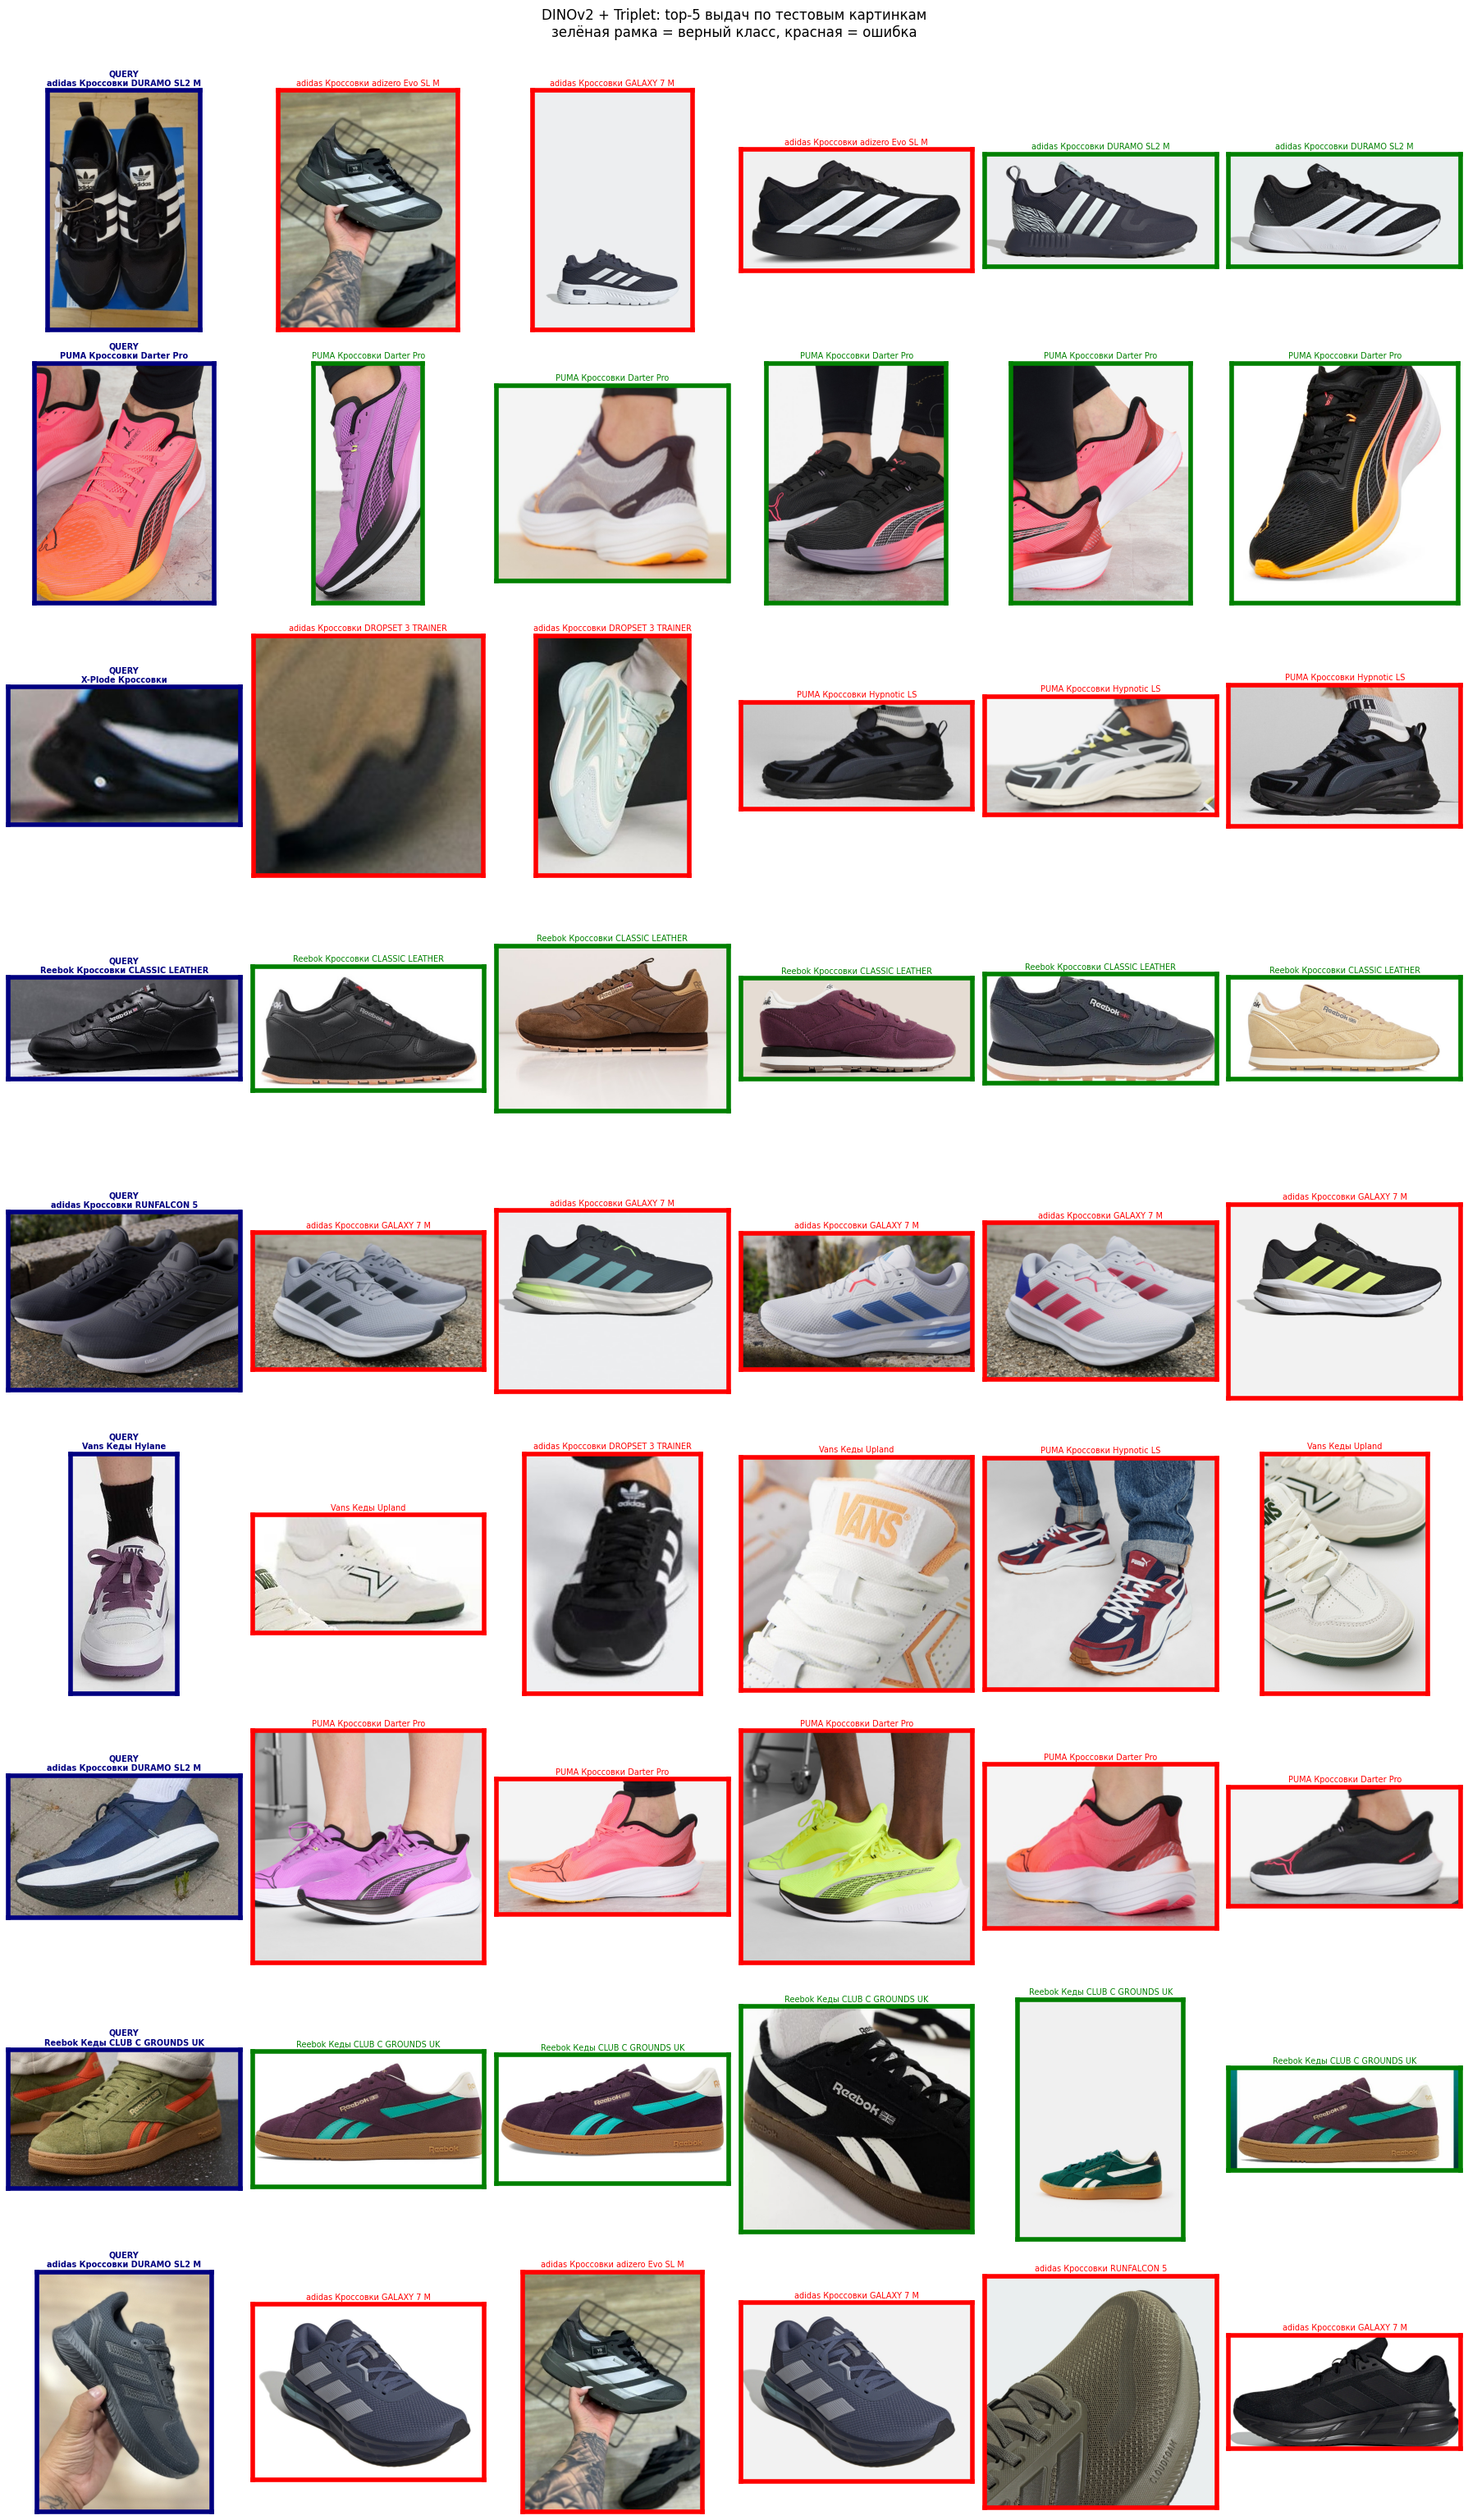

In [15]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

TOP_K  = 5
N_SHOW = 9

path_to_dataset = str(PROJECT_ROOT_PATH / 'data/03_yolo_preprocessed/search-dataset-images')

n_train = len(orig_train_df)
n_val   = len(val_df)

# индекс — train + val (уже прогнаны через triplet model в all_embeddings)
index_embs    = all_embeddings[:n_train + n_val]
index_paths   = orig_train_df["path"].to_list() + val_df["path"].to_list()
index_classes = orig_train_df["class"].to_list() + val_df["class"].to_list()

index_norm = index_embs / (np.linalg.norm(index_embs, axis=1, keepdims=True) + 1e-8)

# тестовые запросы
test_embs    = all_embeddings[n_train + n_val:]
test_paths_v = test_df["path"].to_list()
test_classes = test_df["class"].to_list()

sample_idx = random.sample(range(len(test_paths_v)), N_SHOW)

fig, axes = plt.subplots(N_SHOW, TOP_K + 1, figsize=(3 * (TOP_K + 1), 3.4 * N_SHOW))

def show_img(ax, path, title, border_color, bold=False):
    img = Image.open(os.path.join(path_to_dataset, path)).convert("RGB")
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)
    ax.set_title(title, fontsize=7, color=border_color,
                 fontweight="bold" if bold else "normal", pad=4)

for row, idx in enumerate(sample_idx):
    query_path  = test_paths_v[idx]
    query_class = test_classes[idx]
    query_norm  = test_embs[idx] / (np.linalg.norm(test_embs[idx]) + 1e-8)

    sims     = index_norm @ query_norm
    top_idxs = np.argsort(-sims)[:TOP_K]

    show_img(axes[row, 0], query_path,
             title=f"QUERY\n{query_class}", border_color="navy", bold=True)

    for col, ret_i in enumerate(top_idxs):
        correct = index_classes[ret_i] == query_class
        color   = "green" if correct else "red"
        show_img(axes[row, col + 1], index_paths[ret_i],
                 title=index_classes[ret_i], border_color=color)

plt.suptitle(
    "DINOv2 + Triplet: top-5 выдач по тестовым картинкам\n"
    "зелёная рамка = верный класс, красная = ошибка",
    fontsize=12, y=1.002
)
plt.tight_layout()
plt.show()